# TP2 PROCESAMIENTO DEL HABLA

**Alumno:** Augusto Presfraind

**Tema elegido:** discurso de Malala Yousafzai, *“Que nadie sea olvidado”*.

En este trabajo práctico resolví la consigna usando **webscrapping + preprocesamiento de texto en español**.  
La idea fue:

1. extraer el discurso desde una página web,
2. identificar las stop words presentes,
3. limpiar el texto,
4. generar una nube de palabras,
5. construir una matriz documento-vocabulario,
6. aplicar TF-IDF para ponderar la importancia de los términos.

> **Nota:** el notebook intenta descargar el texto directamente desde la web.  
> Si el sitio no responde o cambia su estructura, uso un **texto de respaldo** ya guardado para que la notebook siga siendo reproducible.



### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Para esta parte elegí una publicación de **Amnistía Internacional España** que contiene el discurso de **Malala Yousafzai**.

La estrategia fue:

- enviar una solicitud HTTP con `requests`,
- parsear el HTML con `BeautifulSoup`,
- convertir la página a texto plano,
- localizar con una expresión regular el bloque del discurso,
- guardar ese texto en una variable para trabajar luego el preprocesamiento.

También dejé un respaldo del texto para que el notebook pueda correrse incluso si la página no está accesible en el momento de la ejecución.


Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

En este caso trabajé con el discurso de **Malala Yousafzai**. La extracción se hace desde una única URL y luego se limpia el resultado para quedarme solo con el discurso.

Abajo agrego el código y explico paso a paso cómo descargué el texto de interés.


In [5]:
# Instala dependencias necesarias (se ejecuta solo si falta)
import sys, subprocess
packages = [
    'pandas',
    'matplotlib',
    'wordcloud',
    'beautifulsoup4',
    'scikit-learn',
    'requests'
]
for pkg in packages:
    name = pkg.split('==')[0]
    try:
        __import__(name)
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
print('Dependencias instaladas (si hacía falta)')


Dependencias instaladas (si hacía falta)


In [6]:

# =========================
# 1) WEBSCRAPPING DEL TEXTO
# =========================

import re
import unicodedata
from collections import Counter

import requests
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# URL elegida para el trabajo
url = "https://www.es.amnesty.org/en-que-estamos/noticias/noticia/articulo/discurso-de-malala-que-nadie-sea-olvidado/"

# Texto de respaldo:
# lo dejo para que el notebook siga funcionando si la página cambia
# o si no hay conexión al momento de ejecutar.
texto_respaldo = """
Queridos y respetados hermanos y hermanas, secretario general Salil Shetty, señor alcalde,
señor ministro de Educación, Bono, Roger Waters y Harry Belafonte:

Es un gran honor para mí estar de nuevo aquí en Irlanda, donde los ojos siempre sonríen y
se oye a los ángeles cantar. La vez anterior fui invitada a Tipperary, cuyos bellos paisajes
me recordaron a mi ciudad, Swat, con sus exuberantes colinas verdes, sus montañas con altos
árboles y sus ríos cristalinos. Decimos que Swat es un paraíso terrenal, e Irlanda comparte
esa belleza. Pero, además de la belleza natural de esta tierra, para mí lo más importante es
el cariño y la amabilidad que sus habitantes me han demostrado.

Agradezco a Amnistía Internacional su constante actividad de campaña para proteger los derechos
humanos y que me haya concedido este premio por nuestra campaña mundial en favor de la educación
de las niñas. Me siento realmente honrada de compartir hoy este galardón con el rey, no sólo del
Calipso, sino de las campañas en favor de los derechos humanos en todo el mundo. Le admiro
profundamente, señor Belafonte.

Queridos hermanos y hermanas, como muchos de ustedes saben, mi amado país, Pakistán, y su pueblo
sufre a manos de la violencia terrorista. Continúa librándose una guerra contra civiles inocentes
en Afganistán y las niñas de todo el mundo se ven privadas de su derecho básico a la educación.
Niñas como Sambul, de 5 años, son víctimas de la violencia sexual. Se asesina a defensoras de los
derechos humanos como Sushmita Banerjee, escritora y trabajadora de la salud, que murió abatida a
tiros en Afganistán. Vemos que en Siria la gente se queda sin hogar y los niños y niñas no pueden
ir a la escuela. En India, las niñas y los niños son víctima del trabajo infantil y de la trata.

En muchos países las mujeres son víctimas de abusos sexuales, matrimonios forzados a edad temprana
y trabajo doméstico. No se acepta que son seres humanos. Se las considera seres inferiores, se las
desatiende y se las margina. A las mujeres se las priva de su derecho básico a la igualdad y la
justicia. Podría seguir hablando mucho tiempo de las atrocidades y las violaciones de derechos
humanos que ocurren cada hora, cada minuto y cada segundo de cada día.

Sé que cuando alguien sube aquí y pronuncia un discurso, el público aplaude y ahí acaba todo.
Queridos hermanos y hermanas, no estoy aquí para entrar en detalles sobre los problemas a los que
nos enfrentamos. Estoy aquí, como todos, para buscar una solución a estos problemas. Y puede que
ustedes se estén preguntando: ¿cuál es la solución? Yo creo que la única solución es educación,
educación y más educación.

Con esta poderosa arma podemos combatir la violencia, el terrorismo, el trabajo infantil y la
desigualdad. Las únicas herramientas necesarias son un lápiz y un libro para guiarnos en nuestro
camino hacia un futuro mejor para todas las personas.

Hoy quisiera pedirles a todos que después de este acto hagan una cosa muy sencilla: que tomen papel
y lápiz y escriban a sus gobiernos pidiéndoles que se centren en la educación y que actúen realmente.
Es fundamental que la educación sea su principal prioridad. Quiero vivir en un mundo donde la educación
obligatoria gratuita esté al alcance de todos los niños y niñas en todas partes. Que nadie sea olvidado.
""".strip()

def extraer_discurso_desde_web(url: str):
    """
    Intenta descargar y extraer el discurso desde la página web.
    Si falla, devuelve el texto de respaldo.
    """
    headers = {"User-Agent": "Mozilla/5.0"}

    try:
        respuesta = requests.get(url, headers=headers, timeout=20)
        respuesta.raise_for_status()

        soup = BeautifulSoup(respuesta.text, "html.parser")

        # Convierto todo el HTML a texto para buscar el tramo del discurso
        texto_pagina = soup.get_text(" ", strip=True)

        # El artículo incluye el discurso después de "Estas fueron sus palabras:"
        # y termina con la frase "Que nadie sea olvidado."
        patron = r"Estas fueron sus palabras:\s*(.*?)\s*Que nadie sea olvidado\."
        hallado = re.search(patron, texto_pagina, flags=re.DOTALL | re.IGNORECASE)

        if hallado:
            texto_extraido = hallado.group(1).strip() + " Que nadie sea olvidado."
            texto_extraido = re.sub(r"\s+", " ", texto_extraido)
            return texto_extraido, "extraído desde la web"

        # Si la estructura cambió y no encuentra el patrón, uso respaldo
        return texto_respaldo, "texto de respaldo (no se encontró el patrón)"

    except Exception as e:
        return texto_respaldo, f"texto de respaldo ({type(e).__name__})"

texto_discurso, origen_texto = extraer_discurso_desde_web(url)

print("Origen del texto:", origen_texto)
print("Cantidad de caracteres:", len(texto_discurso))
print("\nPrimeros 900 caracteres del discurso:\n")
print(texto_discurso[:900])


Origen del texto: extraído desde la web
Cantidad de caracteres: 3305

Primeros 900 caracteres del discurso:

Queridos y respetados hermanos y hermanas, secretario general Salil Shetty, señor alcalde, señor ministro de Educación, Bono, Roger Waters y Harry Belafonte: Es un gran honor para mí estar de nuevo aquí en Irlanda, donde los ojos siempre sonríen y se oye a los ángeles cantar. La vez anterior fui invitada a Tipperary, cuyos bellos paisajes me recordaron a mi ciudad, Swat, con sus exuberantes colinas verdes, sus montañas con altos árboles y sus ríos cristalinos. Decimos que Swat es un paraíso terrenal, e Irlanda comparte esa belleza. Pero, además de la belleza natural de esta tierra, para mí lo más importante es el cariño y la amabilidad que sus habitantes me han demostrado. Agradezco a Amnistía Internacional su constante actividad de campaña para proteger los derechos humanos y que me haya concedido este premio por nuestra campaña mundial en favor de la educación de las niñas. Me

## 2- Preprocesamiento

Una vez obtenido el discurso, comienzo el preprocesamiento del texto en español.

En esta parte:
- detecto qué stop words aparecen,
- limpio signos y caracteres no deseados,
- elimino palabras vacías,
- genero una nube de palabras,
- separo el texto en oraciones para construir la matriz documento-vocabulario,
- finalmente aplico TF-IDF.


### 2.1 Muestra las stop words que tenga tu texto.

Primero defino una lista de stop words en español y luego identifico cuáles aparecen efectivamente dentro del discurso.


In [7]:

# ===================================
# 2.1 STOP WORDS PRESENTES EN EL TEXTO
# ===================================

stopwords_es = {
    "de","la","que","el","en","y","a","los","del","se","las","por","un","para","con","no","una",
    "su","al","lo","como","más","pero","sus","le","ya","o","este","sí","porque","esta","entre",
    "cuando","muy","sin","sobre","también","me","hasta","hay","donde","quien","desde","todo",
    "nos","durante","todos","uno","les","ni","contra","otros","ese","eso","ante","ellos","e",
    "esto","mí","antes","algunos","qué","unos","yo","otro","otras","otra","él","tanto","esa",
    "estos","mucho","quienes","nada","muchos","cual","poco","ella","estar","estas","algunas",
    "algo","nosotros","mi","mis","tú","te","ti","tu","tus","ellas","nosotras","vosotros","vosotras",
    "os","mío","mía","míos","mías","tuyo","tuya","tuyos","tuyas","suyo","suya","suyos","suyas",
    "nuestro","nuestra","nuestros","nuestras","vuestro","vuestra","vuestros","vuestras","esos",
    "esas","estoy","está","están","estaba","estamos","están","sea","son","ser","es","fue","fui","fueron",
    "ha","han","he","hoy","aquí","allí","cada","tras","si","u","ahí","toda","aun","aún","además",
    "solo","sólo","después","cosa","cosas","puede","pueden","puedo","puedan","hacia","través",
    "cuyo","cuyos","cuyas","cuales","cualquier","cualquiera","casi"
}

tokens_originales = re.findall(r"\b[\wáéíóúñüÁÉÍÓÚÑÜ]+\b", texto_discurso.lower())

stopwords_presentes = sorted(set(token for token in tokens_originales if token in stopwords_es))
conteo_stopwords = Counter(token for token in tokens_originales if token in stopwords_es)

print("Cantidad de stop words distintas encontradas:", len(stopwords_presentes))
print("\nStop words presentes en el discurso:\n")
print(stopwords_presentes)

print("\nLas 15 stop words más frecuentes:\n")
print(conteo_stopwords.most_common(15))


Cantidad de stop words distintas encontradas: 66

Stop words presentes en el discurso:

['a', 'además', 'ahí', 'al', 'aquí', 'cada', 'como', 'con', 'contra', 'cosa', 'cuando', 'cuyos', 'de', 'del', 'después', 'donde', 'e', 'el', 'en', 'es', 'esa', 'esta', 'estar', 'este', 'estos', 'estoy', 'fui', 'hacia', 'han', 'hoy', 'la', 'las', 'le', 'lo', 'los', 'me', 'mi', 'mucho', 'muchos', 'muy', 'más', 'mí', 'no', 'nos', 'nuestra', 'nuestro', 'para', 'pero', 'por', 'puede', 'pueden', 'que', 'se', 'sea', 'sin', 'sobre', 'son', 'su', 'sus', 'sólo', 'todo', 'todos', 'un', 'una', 'y', 'yo']

Las 15 stop words más frecuentes:

[('y', 31), ('de', 26), ('la', 20), ('que', 17), ('a', 16), ('en', 14), ('las', 14), ('se', 11), ('los', 10), ('un', 7), ('para', 7), ('el', 7), ('es', 6), ('sus', 5), ('su', 5)]


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca `wordcloud` de python.

En este paso convierto todo a minúsculas, elimino signos de puntuación, conservo letras del español y saco las stop words para quedarme con las palabras más informativas del discurso.


Cantidad de palabras luego de limpiar y quitar stop words: 273

20 palabras más frecuentes del texto limpio:

[('educación', 9), ('niñas', 6), ('humanos', 5), ('derechos', 4), ('queridos', 3), ('hermanos', 3), ('hermanas', 3), ('señor', 3), ('mundo', 3), ('violencia', 3), ('niños', 3), ('trabajo', 3), ('solución', 3), ('belafonte', 2), ('irlanda', 2), ('swat', 2), ('belleza', 2), ('campaña', 2), ('favor', 2), ('realmente', 2)]


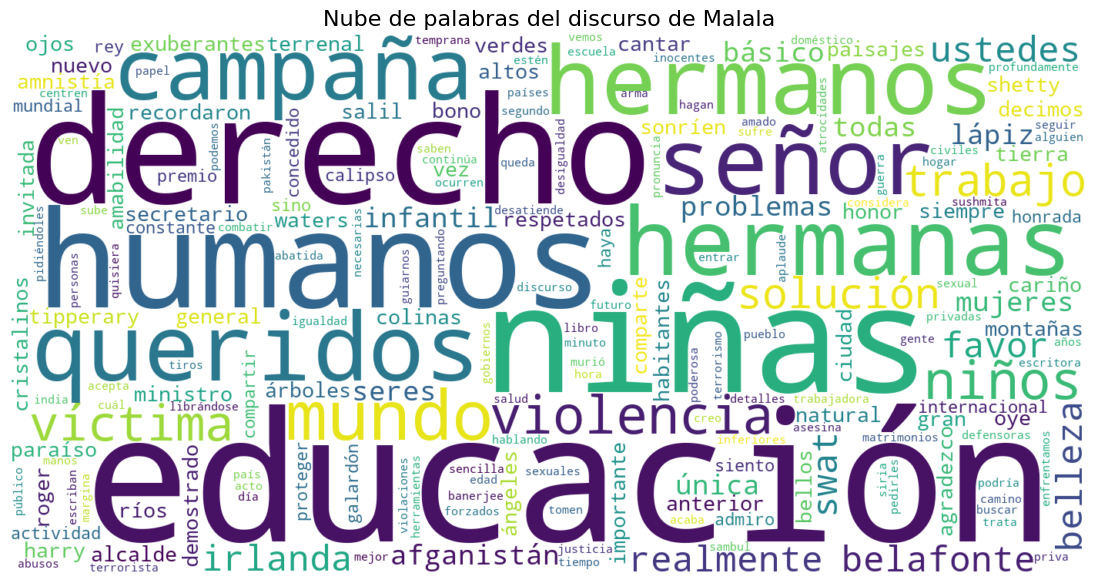

In [8]:

# ======================================
# 2.2 LIMPIEZA DEL TEXTO Y NUBE DE PALABRAS
# ======================================

def normalizar_texto(texto: str, quitar_acentos: bool = False) -> str:
    texto = texto.lower()

    if quitar_acentos:
        texto = "".join(
            c for c in unicodedata.normalize("NFD", texto)
            if unicodedata.category(c) != "Mn"
        )

    patron = r"[^a-záéíóúñü\s]" if not quitar_acentos else r"[^a-zñü\s]"
    texto = re.sub(patron, " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

texto_limpio = normalizar_texto(texto_discurso, quitar_acentos=False)

tokens_limpios = [
    token for token in texto_limpio.split()
    if token not in stopwords_es and len(token) > 2
]

texto_sin_stopwords = " ".join(tokens_limpios)

print("Cantidad de palabras luego de limpiar y quitar stop words:", len(tokens_limpios))
print("\n20 palabras más frecuentes del texto limpio:\n")
print(Counter(tokens_limpios).most_common(20))

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    collocations=False
).generate(texto_sin_stopwords)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras del discurso de Malala", fontsize=16)
plt.show()


### 2.3 Usando el texto que conseguiste en el punto 1)

Ahora tomo el discurso ya extraído y lo convierto en una estructura más útil para análisis cuantitativo.


#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.

Voy a considerar **cada oración como un documento**.  
Luego uso `CountVectorizer` para construir la matriz documento-vocabulario, donde:
- las filas son oraciones,
- las columnas son términos,
- los valores son frecuencias.


In [9]:

# ==========================================================
# 2.3.1 ORACIONES + MATRIZ DOCUMENTO-VOCABULARIO
# ==========================================================

def quitar_acentos(texto: str) -> str:
    return "".join(
        c for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )

def limpiar_para_modelo(texto: str) -> str:
    texto = texto.lower()
    texto = quitar_acentos(texto)
    texto = re.sub(r"[^a-zñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Separo el discurso en oraciones
oraciones = re.split(r'(?<=[.!?])\s+', re.sub(r"\s+", " ", texto_discurso.strip()))
oraciones = [o.strip() for o in oraciones if len(o.strip()) > 20]

print("Cantidad de oraciones/documentos:", len(oraciones))
print("\nPrimeras 3 oraciones:\n")
for i, oracion in enumerate(oraciones[:3], start=1):
    print(f"{i}. {oracion}\n")

# Limpieza orientada al modelado
oraciones_modelo = [limpiar_para_modelo(oracion) for oracion in oraciones]

# También normalizo las stop words para que coincidan con el texto sin acentos
stopwords_modelo = sorted({quitar_acentos(palabra) for palabra in stopwords_es})

vectorizer = CountVectorizer(
    stop_words=stopwords_modelo,
    token_pattern=r"(?u)\b[a-zñü]{2,}\b"
)

matriz_doc_vocab = vectorizer.fit_transform(oraciones_modelo)
vocabulario = vectorizer.get_feature_names_out()

df_dtm = pd.DataFrame(
    matriz_doc_vocab.toarray(),
    columns=vocabulario,
    index=[f"oracion_{i+1}" for i in range(len(oraciones))]
)

print("Dimensión de la matriz documento-vocabulario:", df_dtm.shape)
print("\nVista parcial de la matriz:\n")
display(df_dtm.iloc[:5, :15])


Cantidad de oraciones/documentos: 29

Primeras 3 oraciones:

1. Queridos y respetados hermanos y hermanas, secretario general Salil Shetty, señor alcalde, señor ministro de Educación, Bono, Roger Waters y Harry Belafonte: Es un gran honor para mí estar de nuevo aquí en Irlanda, donde los ojos siempre sonríen y se oye a los ángeles cantar.

2. La vez anterior fui invitada a Tipperary, cuyos bellos paisajes me recordaron a mi ciudad, Swat, con sus exuberantes colinas verdes, sus montañas con altos árboles y sus ríos cristalinos.

3. Decimos que Swat es un paraíso terrenal, e Irlanda comparte esa belleza.

Dimensión de la matriz documento-vocabulario: (29, 216)

Vista parcial de la matriz:



,abatida,abusos,acaba,acepta,actividad,acto,actuen,admiro,afganistan,agradezco,alcalde,alcance,alguien,altos,amabilidad
oracion_1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
oracion_2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
oracion_3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
oracion_4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
oracion_5,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0


#### 2.3.2 Determina la longitud de tu vocabulario.

Aquí calculo cuántos términos distintos quedaron luego de la limpieza y la vectorización.


In [10]:

# ==========================================
# 2.3.2 LONGITUD DEL VOCABULARIO
# ==========================================

longitud_vocabulario = len(vocabulario)

frecuencias_totales = df_dtm.sum(axis=0).sort_values(ascending=False)

print("Longitud del vocabulario:", longitud_vocabulario)
print("\n15 términos más frecuentes del vocabulario:\n")
print(frecuencias_totales.head(15))


Longitud del vocabulario: 216

15 términos más frecuentes del vocabulario:

educacion    9
ninas        6
humanos      5
derechos     4
hermanas     3
hermanos     3
mundo        3
ninos        3
queridos     3
senor        3
trabajo      3
solucion     3
violencia    3
infantil     2
problemas    2
dtype: int64


#### 2.3.3 Aplica TF-IDF a tu matriz documento-vocabulario

Con TF-IDF ya no miro solo cuántas veces aparece una palabra, sino qué tan representativa es dentro de cada oración respecto del resto del discurso.


In [11]:

# ==========================================
# 2.3.3 APLICACIÓN DE TF-IDF
# ==========================================

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stopwords_modelo,
    token_pattern=r"(?u)\b[a-zñü]{2,}\b"
)

matriz_tfidf = tfidf_vectorizer.fit_transform(oraciones_modelo)
vocabulario_tfidf = tfidf_vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vocabulario_tfidf,
    index=[f"oracion_{i+1}" for i in range(len(oraciones))]
)

print("Dimensión de la matriz TF-IDF:", df_tfidf.shape)
print("\nVista parcial de la matriz TF-IDF:\n")
display(df_tfidf.iloc[:5, :15].round(3))

print("\n10 términos con mayor frecuencia total en el corpus (referencia):\n")
print(frecuencias_totales.head(10))


Dimensión de la matriz TF-IDF: (29, 216)

Vista parcial de la matriz TF-IDF:



,abatida,abusos,acaba,acepta,actividad,acto,actuen,admiro,afganistan,agradezco,alcalde,alcance,alguien,altos,amabilidad
oracion_1,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.192,0.0,0.0,0.000,0.000
oracion_2,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.244,0.000
oracion_3,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.000
oracion_4,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.358
oracion_5,0.0,0.0,0.0,0.0,0.245,0.0,0.0,0.0,0.0,0.245,0.000,0.0,0.0,0.000,0.000



10 términos con mayor frecuencia total en el corpus (referencia):

educacion    9
ninas        6
humanos      5
derechos     4
hermanas     3
hermanos     3
mundo        3
ninos        3
queridos     3
senor        3
dtype: int64


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

En mi caso, la matriz documento-vocabulario quedó organizada así:

- **Documentos:** cada documento es una **oración** del discurso.
- **Vocabulario:** cada columna representa una palabra distinta después de la limpieza.
- **Tamaño:** la matriz final quedó con **29 documentos** y **216 términos**.

Esto significa que transformé un texto narrativo en una estructura tabular que ya puede usarse para análisis cuantitativo.  
Con esta matriz pude ver qué términos dominan el discurso y, con TF-IDF, cuáles son más relevantes dentro de cada oración y no solo frecuentes en todo el texto.


# Conclusiones

En este trabajo aprendí a unir varias etapas de un flujo de PLN básico:

1. **extraer texto desde la web**,  
2. **limpiarlo**,  
3. **quitar stop words**,  
4. **visualizarlo con una nube de palabras**,  
5. **representarlo como una matriz documento-vocabulario**,  
6. **aplicar TF-IDF**.

Lo más importante que observé es que, una vez limpio el texto, las palabras que más peso toman reflejan claramente el eje del discurso: **educación, niñas, derechos humanos, violencia, trabajo infantil, mundo y solución**.

También entendí que una misma fuente textual puede analizarse de distintas formas:
- como texto completo para visualización,
- como conjunto de oraciones para modelado,
- como frecuencias simples,
- o como ponderaciones TF-IDF.

La parte más desafiante fue la **extracción del discurso exacto** desde la página web, porque en scraping muchas veces el HTML trae mucho contenido extra. Por eso usé una expresión regular para aislar el bloque relevante y además dejé un respaldo del texto para asegurar reproducibilidad.

Como inquietud final, me queda seguir profundizando en:
- lematización,
- stemming,
- detección automática de entidades,
- y comparación entre frecuencias simples vs TF-IDF en textos más largos.


In [12]:

# ==========================
# RESUMEN FINAL DEL ANÁLISIS
# ==========================

print("Resumen del trabajo")
print("-" * 50)
print("Fuente trabajada:", url)
print("Origen utilizado en esta corrida:", origen_texto)
print("Cantidad de caracteres del discurso:", len(texto_discurso))
print("Cantidad de oraciones/documentos:", len(oraciones))
print("Longitud del vocabulario:", longitud_vocabulario)
print("\nTop 10 términos del discurso limpio:")
for termino, frecuencia in frecuencias_totales.head(10).items():
    print(f"- {termino}: {frecuencia}")


Resumen del trabajo
--------------------------------------------------
Fuente trabajada: https://www.es.amnesty.org/en-que-estamos/noticias/noticia/articulo/discurso-de-malala-que-nadie-sea-olvidado/
Origen utilizado en esta corrida: extraído desde la web
Cantidad de caracteres del discurso: 3305
Cantidad de oraciones/documentos: 29
Longitud del vocabulario: 216

Top 10 términos del discurso limpio:
- educacion: 9
- ninas: 6
- humanos: 5
- derechos: 4
- hermanas: 3
- hermanos: 3
- mundo: 3
- ninos: 3
- queridos: 3
- senor: 3



# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [13]:
# instalar wordcloud
!pip install wordcloud


In [14]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [15]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

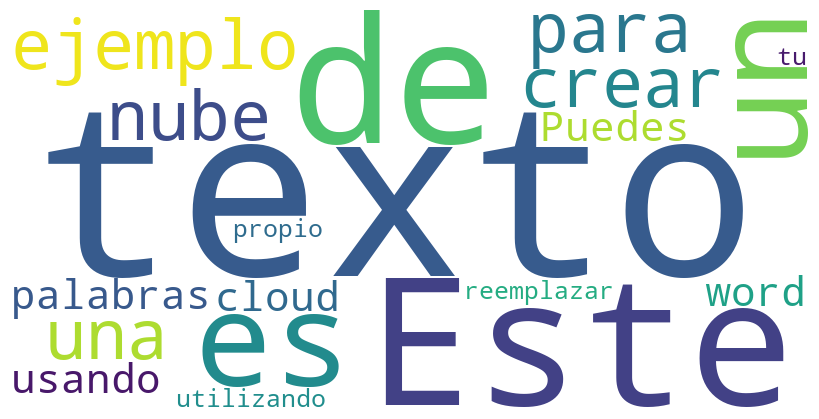

In [16]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



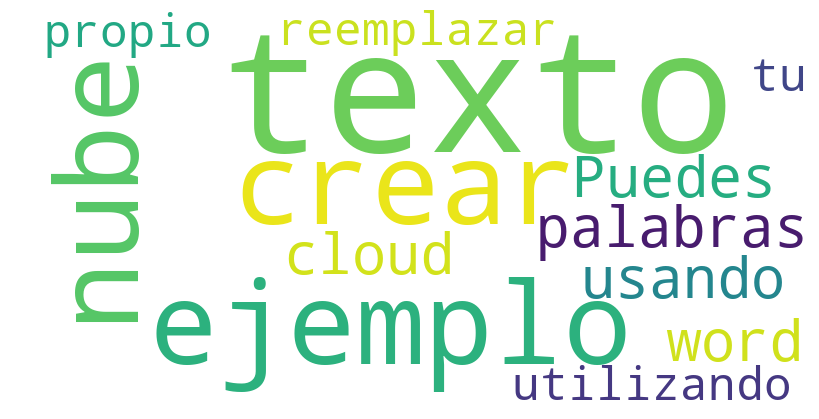

In [17]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
